<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/CNN-model/CNN-dataset3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone --branch CNN-model --single-branch https://github.com/dokunoale/chagas.git
%cd chagas
# Carica librerie installate
!pip install wfdb -q
!pip install gdown -q

# Aggiungi solo la root del progetto (src)
import sys
sys.path.append('/content/chagas/src')

# Importa tutto dai moduli
from preprocessing import tf_dataset_loader
from models import libraries, functions, split_dataset
from models.CNN import build_model

# Importa simboli specifici (se vuoi)
from models.libraries import *
from models.functions import *
from models.split_dataset import *
from models.CNN.build_model import *

Cloning into 'chagas'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 185 (delta 76), reused 84 (delta 42), pack-reused 45 (from 1)
Receiving objects: 100% (185/185), 661.55 KiB | 6.13 MiB/s, done.
Resolving deltas: 100% (81/81), done.
/content/chagas
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas

In [2]:
from google.colab import drive
drive.mount('/content/drive')

url = "https://drive.google.com/file/d/1rB90ehuak-9MLDWh2dZY7rl0pElOK55i/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset

Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1rB90ehuak-9MLDWh2dZY7rl0pElOK55i
From (redirected): https://drive.google.com/uc?id=1rB90ehuak-9MLDWh2dZY7rl0pElOK55i&confirm=t&uuid=b4c5b0cf-8d1a-43c9-9e5b-b647a09162b7
To: /content/chagas/dataset.zip
100%|██████████| 496M/496M [00:03<00:00, 129MB/s]


In [4]:
X_pos, y_pos = tf_dataset_loader.load_dataset('/content/chagas/dataset/preprocessed3/positives')
X_neg, y_neg = tf_dataset_loader.load_dataset('/content/chagas/dataset/preprocessed3/negatives')
#Uniamo i positivi e i negativi
X = np.concatenate([X_pos, X_neg], axis=0)
y = np.concatenate([y_pos, y_neg], axis=0)

# Facciamo lo shuffle
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

# Riordinamento di X e y con gli stessi indici
X = X[indices]
y = y[indices]

#assicuriamoci sia quello giusto
print(X.shape)

(8936, 2800, 12)


In [5]:
#SPLIT DEL DATASET
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)

# Modello

In [6]:
model2 = build_cnn_ecg_model()

#compiliamo il modello
model2.compile(optimizer='adam',
              loss=focal_loss(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("2_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history2 = model2.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)

Epoch 1/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.6047 - auc: 0.6557 - loss: 0.0673
Epoch 1: val_auc improved from -inf to 0.69312, saving model to 2_CNN_best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 123s 691ms/step - accuracy: 0.6048 - auc: 0.6558 - loss: 0.0673 - val_accuracy: 0.5904 - val_auc: 0.6931 - val_loss: 0.0612 - learning_rate: 0.0010
Epoch 2/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.6193 - auc: 0.6913 - loss: 0.0587
Epoch 2: val_auc improved from 0.69312 to 0.69860, saving model to 2_CNN_best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 144s 707ms/step - accuracy: 0.6193 - auc: 0.6913 - loss: 0.0587 - val_accuracy: 0.6318 - val_auc: 0.6986 - val_loss: 0.0603 - learning_rate: 0.0010
Epoch 3/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.6221 - auc: 0.6931 - loss: 0.0578
Epoch 3: val_auc improved from 0.69860 to 0.71122, saving model to 2_CNN_best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 141s 700ms/step - accuracy: 0.6221 - auc: 0.6932 - loss: 0.0578 - val_accuracy: 0.6441 - val_auc: 0.7112 - val_loss: 0.0581 - learning_rate: 0.0010
Epoch 4/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.6258 - auc: 0.7064 - loss: 0.0566
Epoch 4: val_auc improved from 0.71122 to 0.71287, saving model to 2_CNN_best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 142s 700ms/step - accuracy: 0.6259 - auc: 0.7065 - loss: 0.0566 - val_accuracy: 0.6374 - val_auc: 0.7129 - val_loss: 0.0570 - learning_rate: 0.0010
Epoch 5/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.6501 - auc: 0.7180 - loss: 0.0531
Epoch 5: val_auc improved from 0.71287 to 0.72326, saving model to 2_CNN_best_model.h5


...

168/168 ━━━━━━━━━━━━━━━━━━━━ 138s 670ms/step - accuracy: 0.6641 - auc: 0.7445 - loss: 0.0500 - val_accuracy: 0.6525 - val_auc: 0.7390 - val_loss: 0.0526 - learning_rate: 0.0010
Epoch 18/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.6770 - auc: 0.7510 - loss: 0.0479
Epoch 18: val_auc did not improve from 0.73900
168/168 ━━━━━━━━━━━━━━━━━━━━ 145s 688ms/step - accuracy: 0.6769 - auc: 0.7510 - loss: 0.0479 - val_accuracy: 0.6452 - val_auc: 0.7319 - val_loss: 0.0551 - learning_rate: 0.0010
Epoch 19/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.6759 - auc: 0.7434 - loss: 0.0500
Epoch 19: val_auc did not improve from 0.73900
168/168 ━━━━━━━━━━━━━━━━━━━━ 116s 693ms/step - accuracy: 0.6758 - auc: 0.7434 - loss: 0.0500 - val_accuracy: 0.6732 - val_auc: 0.7344 - val_loss: 0.0554 - learning_rate: 0.0010
Epoch 20/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.6679 - auc: 0.7515 - loss: 0.0495
Epoch 20: val_auc did not improve from 0.73900
168/168 ━━━━━━━━━━━

168/168 ━━━━━━━━━━━━━━━━━━━━ 146s 693ms/step - accuracy: 0.6888 - auc: 0.7709 - loss: 0.0455 - val_accuracy: 0.6564 - val_auc: 0.7399 - val_loss: 0.0539 - learning_rate: 5.0000e-04
Epoch 22/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.6936 - auc: 0.7747 - loss: 0.0450
Epoch 22: val_auc improved from 0.73988 to 0.74169, saving model to 2_CNN_best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 144s 703ms/step - accuracy: 0.6935 - auc: 0.7747 - loss: 0.0450 - val_accuracy: 0.6687 - val_auc: 0.7417 - val_loss: 0.0547 - learning_rate: 5.0000e-04
Epoch 23/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.6816 - auc: 0.7735 - loss: 0.0457
Epoch 23: val_auc did not improve from 0.74169
168/168 ━━━━━━━━━━━━━━━━━━━━ 140s 694ms/step - accuracy: 0.6817 - auc: 0.7735 - loss: 0.0457 - val_accuracy: 0.6626 - val_auc: 0.7370 - val_loss: 0.0542 - learning_rate: 5.0000e-04
Epoch 24/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.6856 - auc: 0.7756 - loss: 0.0447
Epoch 24: val_auc did not improve from 0.74169
168/168 ━━━━━━━━━━━━━━━━━━━━ 113s 673ms/step - accuracy: 0.6856 - auc: 0.7756 - loss: 0.0447 - val_accuracy: 0.6715 - val_auc: 0.7361 - val_loss: 0.0566 - learning_rate: 5.0000e-04
Epoch 25/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.6843 - auc: 0.7686 - loss: 0.0457
Epoch 25: val_auc did not improve from 0.74169
168/168

168/168 ━━━━━━━━━━━━━━━━━━━━ 145s 687ms/step - accuracy: 0.6871 - auc: 0.7891 - loss: 0.0426 - val_accuracy: 0.6609 - val_auc: 0.7420 - val_loss: 0.0540 - learning_rate: 2.5000e-04
Epoch 27/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.6995 - auc: 0.7940 - loss: 0.0414
Epoch 27: val_auc improved from 0.74196 to 0.74485, saving model to 2_CNN_best_model.h5


168/168 ━━━━━━━━━━━━━━━━━━━━ 143s 695ms/step - accuracy: 0.6995 - auc: 0.7939 - loss: 0.0414 - val_accuracy: 0.6749 - val_auc: 0.7449 - val_loss: 0.0561 - learning_rate: 2.5000e-04
Epoch 28/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.7052 - auc: 0.7972 - loss: 0.0409
Epoch 28: val_auc did not improve from 0.74485
168/168 ━━━━━━━━━━━━━━━━━━━━ 142s 693ms/step - accuracy: 0.7052 - auc: 0.7972 - loss: 0.0409 - val_accuracy: 0.6821 - val_auc: 0.7412 - val_loss: 0.0622 - learning_rate: 2.5000e-04
Epoch 29/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.7106 - auc: 0.8027 - loss: 0.0399
Epoch 29: val_auc did not improve from 0.74485
168/168 ━━━━━━━━━━━━━━━━━━━━ 142s 695ms/step - accuracy: 0.7105 - auc: 0.8027 - loss: 0.0399 - val_accuracy: 0.6760 - val_auc: 0.7401 - val_loss: 0.0589 - learning_rate: 2.5000e-04
Epoch 30/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.7006 - auc: 0.7949 - loss: 0.0421
Epoch 30: val_auc did not improve from 0.74485
168/168

In [7]:
#Facciamo le predizioni
y_pred_proba = model2.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step
Soglia ottimale: 0.450
Soglia ottimale: 0.4503030776977539


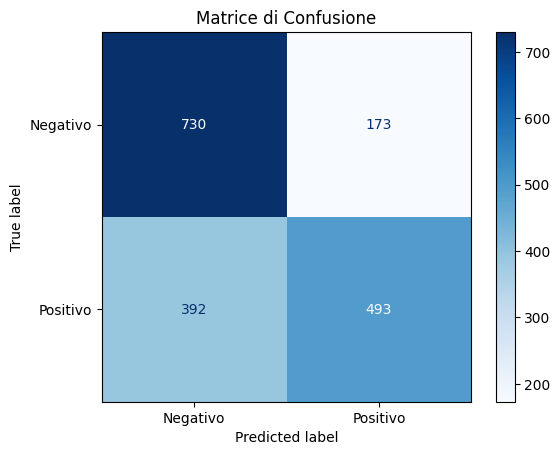

In [8]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm2 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm2)

In [9]:
#Vediamo i risultati
acc1 = accuracy_score(y_test, y_pred_binary)
auc1 = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc1:.3f}")
print(f"AUC: {auc1:.3f}")

class_report1 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report1)
class_report1 = classification_report(y_test, y_pred_binary, output_dict=True )

Accuracy: 0.684
AUC: 0.750
              precision    recall  f1-score   support

    Negativo       0.65      0.81      0.72       903
    Positivo       0.74      0.56      0.64       885

    accuracy                           0.68      1788
   macro avg       0.70      0.68      0.68      1788
weighted avg       0.69      0.68      0.68      1788

